Matthew Martino

# 1. Effects of Contrast, Spatial Frequency, and Eccentricity on Reaction Time

#**2. BACKGROUND**

## Introduction

   The primate visual system processes information through two distinct parallel streams, the parvocellular (P) and magnocellular (M) pathways, which start at the retina and dictate our ability to perceive the visual world. The P pathway is specialized for high-resolution detail (high spatial frequency) and color contrast, particularly red/green isoluminance, but it is primarily concentrated in the center of our vision. Conversely, the M pathway is optimized for rapid motion detection and brightness(luminance) contrast. While this pathway is colorblind, it is distributed across the entire retina, making it the primary driver of peripheral vision. Understanding the constraints of these pathways is essential for explaining why we often struggle to detect certain types of motion in our periphery, which has significant implications for real-world safety and visual ergonomics.


##*Figure 1. Visual References for Relevant Properties*

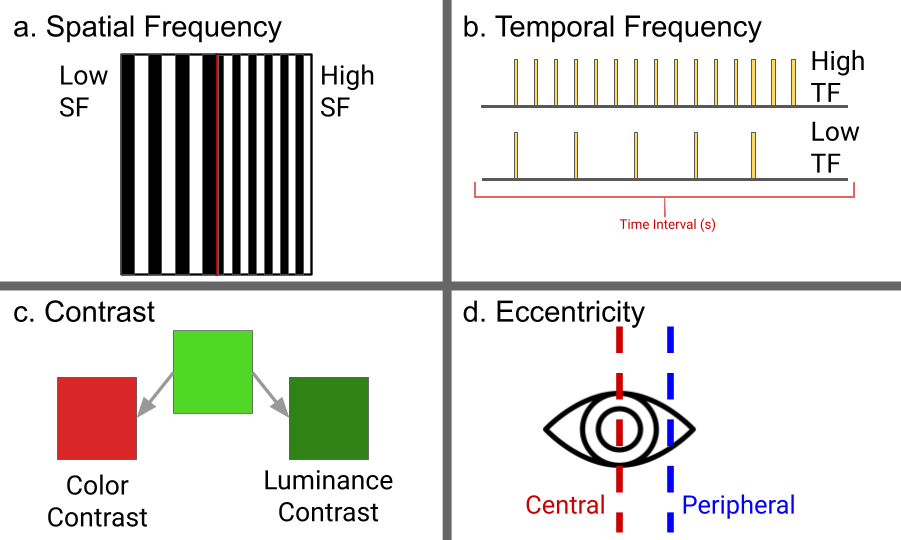

(For review, see Livingstone & Hubel, 1984)

##Experimental Methods

We exploited the sensitivities of each pathway to test motion detection by manipulating the visual properties of a meter stick falling with gravity. Participants (n = 20) responded via button press when they noticed one of four meter sticks start to drop, in central or peripheral vision. Meter sticks were painted with vertically-oriented bands along their length to represent a grating pattern. We manipulated the spatial frequency and contrast of the bands for each meter stick. Two meter sticks had high luminance contrast with black (0.25 cd/m²) and white (5.0 cd/m²) bands. The other two meter sticks were rendered isoluminant (M = 1.3 cd/m² ± 0.2 cd/m²). Spatial frequencies were manipulated by varying band-widths between 9/16" (0.10 c/deg) and 3/16" (0.31 c/deg).

The experiment consisted of four blocks, with eccentricity (central vs peripheral) manipulated between blocks (ABBA design). To force participants to respond to motion at a certain eccentricity, they had to maintain fixation on a cross presented either the left or right side of a computer monitor in front of them. For every trial, the ruler was presented to the right of the monitor. Each block consisted of 32 trials (8 of each stimulus) with four additional training trials at the start of the first and second blocks when participants were first exposed to each eccentricity. Training trials were not recorded.

To initiate a trial, researchers would attach one of the four meter sticks to an electromagnet fixed above participants' field of view and activate a fixation check. Fixations were determined by an eyetracker attached to the bottom of the monitor fixation crosses were presented on. If the eyetracker detected a gaze maintained within 3° of the fixation cross for 0.35 seconds, a trial-specific timer would start. Each trial’s timer was randomized within an exponential decay distribution (minimum = 1 second, maximum = 8 seconds) to reduce participants’ ability to anticipate drop timing. When the timer ended, the meterstick would drop. Participants pressed a button on a response pad held in their lap as fast as they noticed it dropping.

##*Figure 2. Experimental Stimuli(a) and Setup(b)*

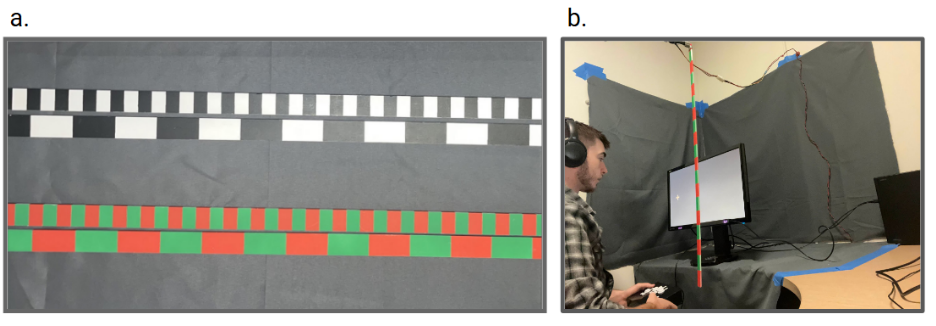

#**3.** **VARIABLES**

   **Subject ID**: *participant* (int)







We had initially collected 26 participants, but excluded 6 (due to dozing off mid-experiment)

**Block Information/Condition**:
* *fixation_cond* - the visual field stimuli were presented in (central or peripheral). In the central condition, stimuli were presented 2 deg visual angle to the left of fixation. In the peripheral conditon, stimuli were presented 30 deg visual angle to the left of fixation. (chr)




Each block consisted of 32 trials with each participant completing four blocks during the experiment.

**Trial Information/Conditions**:

*   *trialNumber* - min 1, max 32 (int)
*   *ruler* - the color pattern of the ruler used (chr)
*   *frequency* - the spatial frequency pattern of the ruler used (chr)
*   *combo* - a combination of ruler and frequency (chr)
*   *rt* - the speed at which the participant pressed a button after the ruler dropped (in milliseconds) (dbl)


2365 trials were included for analysis after removing 9.5% of all trials for falling outside of our inclusion criterion (defined in the next section)

#**4. HYPOTHESES**

The present study hypothesized that RTs would reflect the anatomical and functional constraints of the parvocellular and magnocellular pathways. Specifically, we predicted significant interactions between contrast type, spatial frequency (SF), and eccentricity. We hypothesized that: (1) high SF stimuli would yield slower RTs due to decreased magnocellular pathway sensitivity; (2) isoluminant (red and green) stimuli would yield slower RTs than high luminance contrast (black and white) stimuli as the magnocellular pathway relies on luminance contrast and is largely colorblind; and (3) peripheral presentations would yield slower RTs across all stimuli due to the reduction in retinal ganglion cell density outside the fovea, especially P cells. Furthermore, we predicted (4) the greatest center-to-periphery RT difference would occur for high spatial frequency red/green isoluminant stimuli, as the periphery lacks the parvocellular pathways required to process those stimuli, while the magnocellular pathways are functionally blind to them.


###Formula notation:

The general model for reaction time in our study can be written as:
$$RT = f(C, SF, E) + (1|P) + \epsilon$$
in which the relationship between contrast, spatial frequency, and eccentricity determines reaction time given the random effect of participant due to our repeated measures design. This can also be written as the following mixed effects model:
$$RT_{i} = \beta_0 + \beta_1 C_i + \beta_2 F_i + \beta_3 E_i + \beta_4(C_i \times F_i \times E_i) + \gamma_{P[i]} + \epsilon_i$$

To redefine our hypotheses given a reference level of black and white contrast, low spatial frequency, and central eccentricity, we predict that:

1. Red and green isoluminant trials will have higher reaction times than black and white high luminance trials $$\beta_1 > 0$$

2. High spatial frequency trials will have higher reaction times than low spatial frequency trials $$\beta_2 > 0$$

3. Peripheral eccentricity trials will have higher reaction times than central eccentricity trials $$\beta_3 > 0$$

4. The greatest reaction time deficit will occur when comparing red and green isoluminant, high spatial frequency trials between peripheral and central eccentricities. $$\beta_4 > 0$$

#**5. DATA ORGANIZATION**

####Raw Data into Merged Dataframe

This study was conducted in PsychoPy 2023.1.3. After each block, a csv file was written out by PsychoPy which was merged across all blocks and participants using a for loop in R. An example file name in our raw dataset is "21561_rdtBWRG_2025-11-12_11h54.32.744.csv" in which the first 5 characters represent participant ID followed by the task ID and timestamp of the csv file's creation.

When reading through each block, specific variables of interest were preserved (*participant, ruler, frequency*, drop times, button press times, *fixation_cond, trialNumber*). Trials with missing values for *ruler* were excluded indicating some pre-trial error or that the researcher skipped the trial. Blocks were merged within participants before being added to the full cohort data frame.

The reaction time (*rt*) variable was created by subtracting the time point a ruler dropped from the time point the participant pressed the button. **rt** was multiplied by 1000 to change its units from seconds to milliseconds. After this we removed drop time and press time variables from the data frame. Minimum and maximum reaction time thresholds were set for each participant through a universal standard minimum reaction time (150 ms) and by calculating two standard deviations above the participants' reaction time mean. All trials with reaction times outside of this threshold were excluded (6.5% of trial data).

We also excluded multiple participants for dozing off during our task, removing them from the full dataset.

After exclusions, we merged individual participant data frames to a full cohort dataframe titled "full_CData". Individual trials were marked down by researchers to be filtered from the data pre-analysis due to participant error or loss of focus. Finally we wrote out the complete merged dataframe as a csv file. The data is stored locally in both its raw and merged forms, but will only be uploaded to this notebook post-merge.

###Resulting Dataframe

In [6]:
library(tidyverse)
full_C <- read.csv("https://raw.githubusercontent.com/m4tt-nm/martino_DSPN_S26/refs/heads/master/full_CData.csv")
full_C <- full_C %>%
  rename(combo = stick)
head(full_C)

,ruler,frequency,participant,fixation_cond,trialNumber,rt,combo
,<chr>,<chr>,<int>,<chr>,<int>,<dbl>,<chr>
1,BW,High,21181,central,1,301.0732,BW.High
2,RG,High,21181,central,2,350.4544,RG.High
3,RG,Low,21181,central,3,284.4667,RG.Low
4,BW,Low,21181,central,4,233.3942,BW.Low
5,BW,Low,21181,central,5,317.8640,BW.Low
6,RG,High,21181,central,7,283.5779,RG.High


And to tidy up the dataframe by more cleanly ordering variables/reference levels:


In [7]:
full_C <- full_C %>%
  mutate(
    ruler = fct_relevel(ruler, "BW", "RG"),
    frequency = fct_relevel(frequency, "Low", "High"),
    fixation_cond = fct_relevel(fixation_cond, 'central', 'peripheral'),
    combo = fct_relevel(combo, c('BW.Low', 'RG.Low', 'BW.High', 'RG.High'))) %>%
  select(participant, trialNumber, frequency, ruler, combo, fixation_cond, rt)
head(full_C)

,participant,trialNumber,frequency,ruler,combo,fixation_cond,rt
,<int>,<int>,<fct>,<fct>,<fct>,<fct>,<dbl>
1,21181,1,High,BW,BW.High,central,301.0732
2,21181,2,High,RG,RG.High,central,350.4544
3,21181,3,Low,RG,RG.Low,central,284.4667
4,21181,4,Low,BW,BW.Low,central,233.3942
5,21181,5,Low,BW,BW.Low,central,317.8640
6,21181,7,High,RG,RG.High,central,283.5779


#**6. ANALYSIS**

## Statistical Analysis Steps

6.1 Descriptive Statistics and Initial Visualization

6.2 Generalized Mixed Effects Model For Hypothesis Testing

6.3 Full-subset selection for (Linear) Model Comparison

6.4 Permutation Testing on the Three-Way Interaction

In [17]:
#if (!requireNamespace("ggpattern", quietly = TRUE)) {
  #install.packages("ggpattern", Ncpus = 2) }
#install.packages(c("kableExtra", "moments", "leaps", "lme4", "lmerTest", "emmeans"), Ncpus = 2)
#install.packages("gridExtra")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



###6.1 Descriptive Statistics and Initial Visualization

Make a table of the summary statistics of the sample including:


*   Minimum
*   1st Quartile
*   Median
*   Mean
*   3rd Quartile
*   Maximum
*   Standard Deviation
*   Skewness



In [9]:
library(knitr)
library(moments)
sums_tab <- full_C %>%
  group_by(frequency, ruler, fixation_cond) %>%
  summarize(Min = min(rt), Q1 = quantile(rt, 0.25), Median = median(rt), Mean = mean(rt),
            Q3 = quantile(rt, 0.75), Max = max(rt), SD = sd(rt), Skew = skewness(rt), .groups = 'drop') %>%
  kable(caption = 'Reaction Time Summary Statistics', digits = 2, format = 'markdown')

IRdisplay::display_markdown(paste(sums_tab, collapse = "\n"))

Table: Reaction Time Summary Statistics

|frequency |ruler |fixation_cond |    Min|     Q1| Median|   Mean|     Q3|    Max|    SD| Skew|
|:---------|:-----|:-------------|------:|------:|------:|------:|------:|------:|-----:|----:|
|Low       |BW    |central       | 184.15| 249.59| 267.37| 274.41| 300.09| 534.23| 49.08| 1.63|
|Low       |BW    |peripheral    | 201.19| 250.78| 268.73| 286.76| 316.91| 467.14| 50.09| 1.13|
|Low       |RG    |central       | 217.20| 268.28| 300.90| 309.27| 334.28| 484.68| 46.87| 0.71|
|Low       |RG    |peripheral    | 184.16| 284.32| 317.40| 319.65| 350.36| 550.79| 48.97| 0.91|
|High      |BW    |central       | 184.89| 300.80| 334.49| 342.91| 383.86| 500.33| 58.80| 0.20|
|High      |BW    |peripheral    | 200.25| 316.96| 350.68| 352.08| 384.46| 550.62| 58.79| 0.46|
|High      |RG    |central       | 216.86| 284.67| 334.09| 337.00| 367.77| 484.38| 58.30| 0.31|
|High      |RG    |peripheral    | 216.54| 300.90| 351.37| 359.36| 405.06| 517.73| 66.12| 0.26|

Some notable patterns in the summary statistics are distinctly higher RTs for high spatial frequencies over low spatial frequencies and higher RTs for trials in the peripheral visual field than the central visual field. SDs do not change dramatically between visual fields other than for the red and green, high frequency ruler whose SD drastically increases. Finally, for further analyses, it is crucial to note the positive skew of each condition's distribution. This means that effective hypothesis testing should be performed assuming a non-normal distribution that follows the positive skew pattern of our RT data.

**Visualizing means and standard errors for each condition**


Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine




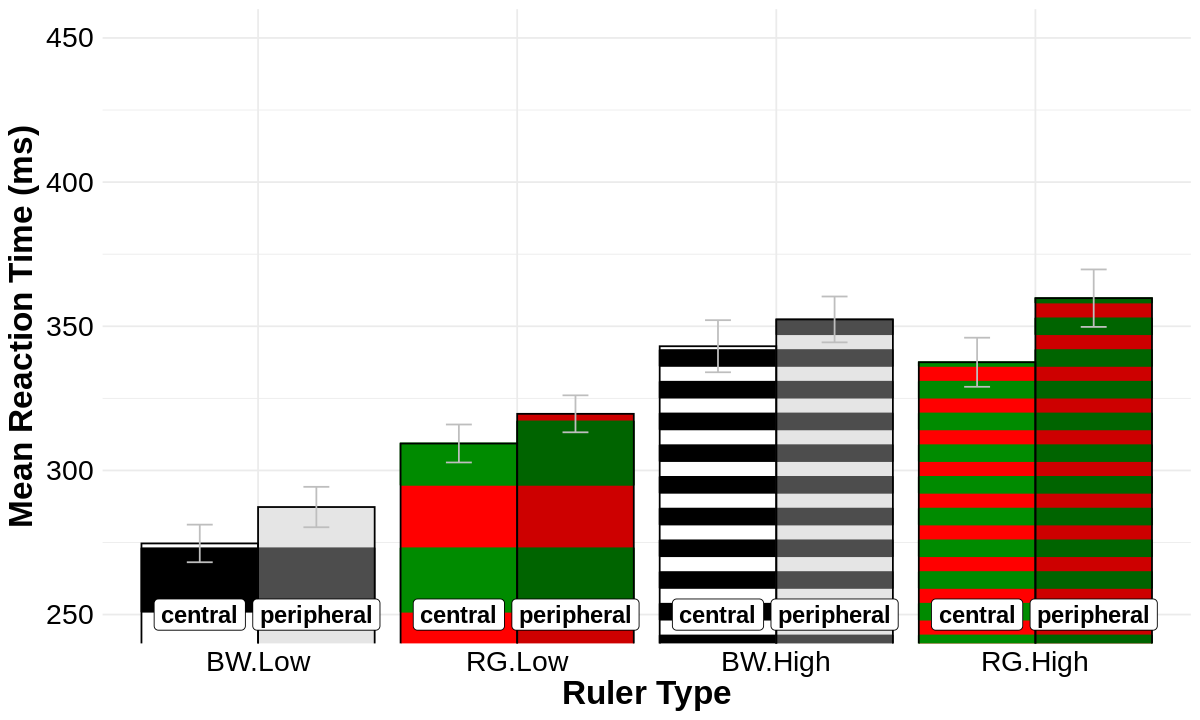

In [18]:
options(repr.plot.width = 10, repr.plot.height = 6)

library(ggplot2)
library(gridExtra)
library(ggpattern)


sum1 <- sum1 <- full_C %>%
  group_by(participant, ruler, frequency, combo, fixation_cond) %>%
  summarize(meanrt = mean(rt), .groups = "drop") %>%
  group_by(ruler, frequency, combo, fixation_cond) %>%
  summarize(meanRT = mean(meanrt),
            sdRT = sd(meanrt),
            count = n(),
            sterr = sdRT/sqrt(count),
            .groups = "drop")

alt_g1 <- ggplot(data=sum1, aes(x=combo, y= meanRT, fill =interaction(fixation_cond, combo))) +
  geom_col_pattern(aes(pattern = frequency, pattern_spacing = frequency, pattern_colour = interaction(fixation_cond, combo), pattern_fill = interaction(fixation_cond, combo)),pattern = "stripe",position = position_dodge(),pattern_angle = 0,pattern_density = .5,color = "black") +
   geom_errorbar(aes(ymin=meanRT-sterr, ymax=meanRT+sterr, group = interaction(combo, fixation_cond)), position = position_dodge(width = 0.9), width=0.2, color = "gray") +
  coord_cartesian(ylim=c(250, 450)) +
  theme_minimal() +
    labs(x = "Ruler Type", y = "Mean Reaction Time (ms)", fill = "Fixation Condition", pattern_spacing = "Spatial Frequency") +
  scale_fill_manual(values = c("white", "gray90", "red", "red3", "white", "gray90", "red", "red3")) +
  scale_pattern_spacing_manual(labels = c("High Spatial Frequency", "Low Spatial Frequency"), values = c(0.2, 0.05)) +
  scale_pattern_color_manual(values = c("black","grey30", "green4", "darkgreen", "black","grey30", "green4", "darkgreen")) +
  scale_pattern_fill_manual(values = c("black","grey30", "green4", "darkgreen", "black","grey30", "green4", "darkgreen")) +
  guides(pattern_color = "none", pattern_fill = "none", fill = "none", pattern_spacing = "none") +
  scale_x_discrete(limits = c("BW.Low", "RG.Low", "BW.High", "RG.High")) +
  geom_label(data = sum1, aes(x = combo, y = c(250, 250, 250, 250, 250, 250, 250, 250), label = fixation_cond, group = interaction(combo, fixation_cond)),inherit.aes = FALSE, fontface = "bold", position = position_dodge(0.9), size = 5) +
    theme(
        axis.text.y = element_text(color = "black", size = 17),
        axis.title.y = element_text(size = 20,
                                  color = "black",
                                  face = "bold"),
        axis.text.x = element_text(color = "black", size = 17),
        axis.title.x = element_text(size = 20,
                                  color = "black",
                                  face = "bold"))

alt_g1

Error bars here are SE. Visually, the main effects of visual field (central vs peripheral) and spatial frequency (low vs high) seem to persist. Interestingly when looking at black and white vs red and green within each spatial frequency group, it appears as though the low frequency group has a more uniform upward shift in reaction time, while the high frequency group is defined by a similar mean value both black and white as well as red and green sit around.

This exploration provides incentive to undergo more rigorous analysis as a few of our hypotheses seem to be quite obvious even visually.

###6.2 Generalized Mixed Effects Model For Hypothesis Testing

We chose a mixed effects model because of the repeated measures nature of data collection and held participant as a random effect.
To best fit the right-skewness of the data, a generalized mixed effects model following a gamma distribution was employed rather than a linear mixed effects model. Log-normal distributions have also been shown to work well with RT analysis, so applying a log transformation to the data and running normal-distribution analyses would also likely be effective.

Our model follows this formula:
$RT \sim Ruler * Frequency * Fixation + (1|Participant)$

In [14]:
library(lme4)
library(kableExtra)
model <- glmer(rt ~ ruler * frequency * fixation_cond + (1 | participant),
                   data = full_C,
                   family = Gamma(link = "identity"),
                   control = glmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 100000)))
gmem_anova <- anova(model)
gmem_tab <- as.data.frame(gmem_anova) %>%
  kable(digits = 3, caption = "ANOVA Results for Gamma Mixed-Effects Model") %>%
  kable_styling(bootstrap_options = c("striped", "hover", "condensed"), full_width = FALSE)

IRdisplay::display_markdown(paste(gmem_tab, collapse = "\n"))

<table class="table table-striped table-hover table-condensed" style="width: auto !important; margin-left: auto; margin-right: auto;">
<caption>ANOVA Results for Gamma Mixed-Effects Model</caption>
 <thead>
  <tr>
   <th style="text-align:left;">  </th>
   <th style="text-align:right;"> npar </th>
   <th style="text-align:right;"> Sum Sq </th>
   <th style="text-align:right;"> Mean Sq </th>
   <th style="text-align:right;"> F value </th>
  </tr>
 </thead>
<tbody>
  <tr>
   <td style="text-align:left;"> ruler </td>
   <td style="text-align:right;"> 1 </td>
   <td style="text-align:right;"> 3.057 </td>
   <td style="text-align:right;"> 3.057 </td>
   <td style="text-align:right;"> 145.155 </td>
  </tr>
  <tr>
   <td style="text-align:left;"> frequency </td>
   <td style="text-align:right;"> 1 </td>
   <td style="text-align:right;"> 14.468 </td>
   <td style="text-align:right;"> 14.468 </td>
   <td style="text-align:right;"> 687.086 </td>
  </tr>
  <tr>
   <td style="text-align:left;"> fixation_cond </td>
   <td style="text-align:right;"> 1 </td>
   <td style="text-align:right;"> 1.073 </td>
   <td style="text-align:right;"> 1.073 </td>
   <td style="text-align:right;"> 50.943 </td>
  </tr>
  <tr>
   <td style="text-align:left;"> ruler:frequency </td>
   <td style="text-align:right;"> 1 </td>
   <td style="text-align:right;"> 1.745 </td>
   <td style="text-align:right;"> 1.745 </td>
   <td style="text-align:right;"> 82.875 </td>
  </tr>
  <tr>
   <td style="text-align:left;"> ruler:fixation_cond </td>
   <td style="text-align:right;"> 1 </td>
   <td style="text-align:right;"> 0.021 </td>
   <td style="text-align:right;"> 0.021 </td>
   <td style="text-align:right;"> 1.011 </td>
  </tr>
  <tr>
   <td style="text-align:left;"> frequency:fixation_cond </td>
   <td style="text-align:right;"> 1 </td>
   <td style="text-align:right;"> 0.022 </td>
   <td style="text-align:right;"> 0.022 </td>
   <td style="text-align:right;"> 1.038 </td>
  </tr>
  <tr>
   <td style="text-align:left;"> ruler:frequency:fixation_cond </td>
   <td style="text-align:right;"> 1 </td>
   <td style="text-align:right;"> 0.081 </td>
   <td style="text-align:right;"> 0.081 </td>
   <td style="text-align:right;"> 3.866 </td>
  </tr>
</tbody>
</table>

The three main effects(ruler, frequency, and fixation_cond) all have large F values which along with our initial exploration supports hypotheses of

1. $$\beta_{ruler} > 0$$
2. $$\beta_{frequency} > 0$$
3. $$\beta_{eccentricity} > 0$$

However, p-value of our three way interaction F-statistic $$F(1, 2365) = 3.866$$ is p = .0049. Barely significant even though it does support our last hypothesis

4. $$\beta_{rfc} > 0$$

**Estimating and testing means of our model**

In [67]:
library(emmeans)

emm_ests <- emmeans(model, ~ ruler * frequency * fixation_cond, type = "response")
emm_data <- as.data.frame(emm_ests)
emm_table <- emm_data %>%
  mutate(across(where(is.numeric), ~ round(., 2))) %>%
  rename(
    "Condition Mean (ms)" = emmean,
    "Lower CI" = asymp.LCL,
    "Upper CI" = asymp.UCL,
    "Ruler" = ruler,
    "Freq" = frequency,
    "Fixation" = fixation_cond
  ) %>%
  select(Ruler, Freq, Fixation, `Condition Mean (ms)`, SE, `Lower CI`, `Upper CI`)

emm_html <- emm_table %>%
  kable(caption = "Estimated Marginal Means (Response Scale) for 3-Way Interaction",
        align = "lllcccc") %>%
  kable_styling(bootstrap_options = c("striped", "hover", "condensed"),
                full_width = FALSE,
                position = "left") %>%
  column_spec(4, bold = TRUE)
IRdisplay::display_markdown(paste(emm_html, collapse = "\n"))

em_3way <- emmeans(model, ~ ruler * frequency * fixation_cond)
pairs_results <- pairs(em_3way, by = c("ruler", "frequency"), adjust = "tukey")
pairs_df <- as.data.frame(pairs_results)
pairs_table <- pairs_df %>%
  mutate(across(c(estimate, SE, df, z.ratio), ~ round(., 2))) %>%
  rename(
    "Ruler" = ruler,
    "Freq" = frequency,
    "Contrast (Fixation)" = contrast,
    "Estimate" = estimate,
    "SE" = SE,
    "df" = df,
    "z-ratio" = z.ratio,
    "p-value" = p.value)

pairs_html <- pairs_table %>%
  kable(
    caption = "Pairwise Comparisons of Fixation Condition by Ruler and Frequency (Tukey Adjusted)",
    align = "lllccccc"
  ) %>%
  kable_styling(
    bootstrap_options = c("striped", "hover", "condensed"),
    full_width = FALSE,
    position = "left"
  ) %>%
  column_spec(8, bold = TRUE) %>%
  collapse_rows(columns = 1:2, valign = "top")


IRdisplay::display_markdown(paste(pairs_html, collapse = "\n"))

<table class="table table-striped table-hover table-condensed" style="width: auto !important; ">
<caption>Estimated Marginal Means (Response Scale) for 3-Way Interaction</caption>
 <thead>
  <tr>
   <th style="text-align:left;"> Ruler </th>
   <th style="text-align:left;"> Freq </th>
   <th style="text-align:left;"> Fixation </th>
   <th style="text-align:center;"> Condition Mean (ms) </th>
   <th style="text-align:center;"> SE </th>
   <th style="text-align:center;"> Lower CI </th>
   <th style="text-align:center;"> Upper CI </th>
  </tr>
 </thead>
<tbody>
  <tr>
   <td style="text-align:left;"> BW </td>
   <td style="text-align:left;"> Low </td>
   <td style="text-align:left;"> central </td>
   <td style="text-align:center;font-weight: bold;"> 278.37 </td>
   <td style="text-align:center;"> 7.80 </td>
   <td style="text-align:center;"> 263.08 </td>
   <td style="text-align:center;"> 293.66 </td>
  </tr>
  <tr>
   <td style="text-align:left;"> RG </td>
   <td style="text-align:left;"> Low </td>
   <td style="text-align:left;"> central </td>
   <td style="text-align:center;font-weight: bold;"> 313.42 </td>
   <td style="text-align:center;"> 7.93 </td>
   <td style="text-align:center;"> 297.87 </td>
   <td style="text-align:center;"> 328.97 </td>
  </tr>
  <tr>
   <td style="text-align:left;"> BW </td>
   <td style="text-align:left;"> High </td>
   <td style="text-align:left;"> central </td>
   <td style="text-align:center;font-weight: bold;"> 346.52 </td>
   <td style="text-align:center;"> 7.93 </td>
   <td style="text-align:center;"> 330.99 </td>
   <td style="text-align:center;"> 362.06 </td>
  </tr>
  <tr>
   <td style="text-align:left;"> RG </td>
   <td style="text-align:left;"> High </td>
   <td style="text-align:left;"> central </td>
   <td style="text-align:center;font-weight: bold;"> 339.73 </td>
   <td style="text-align:center;"> 8.01 </td>
   <td style="text-align:center;"> 324.03 </td>
   <td style="text-align:center;"> 355.44 </td>
  </tr>
  <tr>
   <td style="text-align:left;"> BW </td>
   <td style="text-align:left;"> Low </td>
   <td style="text-align:left;"> peripheral </td>
   <td style="text-align:center;font-weight: bold;"> 290.98 </td>
   <td style="text-align:center;"> 7.84 </td>
   <td style="text-align:center;"> 275.61 </td>
   <td style="text-align:center;"> 306.34 </td>
  </tr>
  <tr>
   <td style="text-align:left;"> RG </td>
   <td style="text-align:left;"> Low </td>
   <td style="text-align:left;"> peripheral </td>
   <td style="text-align:center;font-weight: bold;"> 323.44 </td>
   <td style="text-align:center;"> 8.00 </td>
   <td style="text-align:center;"> 307.75 </td>
   <td style="text-align:center;"> 339.12 </td>
  </tr>
  <tr>
   <td style="text-align:left;"> BW </td>
   <td style="text-align:left;"> High </td>
   <td style="text-align:left;"> peripheral </td>
   <td style="text-align:center;font-weight: bold;"> 355.86 </td>
   <td style="text-align:center;"> 8.12 </td>
   <td style="text-align:center;"> 339.94 </td>
   <td style="text-align:center;"> 371.78 </td>
  </tr>
  <tr>
   <td style="text-align:left;"> RG </td>
   <td style="text-align:left;"> High </td>
   <td style="text-align:left;"> peripheral </td>
   <td style="text-align:center;font-weight: bold;"> 361.50 </td>
   <td style="text-align:center;"> 8.12 </td>
   <td style="text-align:center;"> 345.59 </td>
   <td style="text-align:center;"> 377.41 </td>
  </tr>
</tbody>
</table>

<table class="table table-striped table-hover table-condensed" style="width: auto !important; ">
<caption>Pairwise Comparisons of Fixation Condition by Ruler and Frequency (Tukey Adjusted)</caption>
 <thead>
  <tr>
   <th style="text-align:left;"> Contrast (Fixation) </th>
   <th style="text-align:left;"> Ruler </th>
   <th style="text-align:left;"> Freq </th>
   <th style="text-align:center;"> Estimate </th>
   <th style="text-align:center;"> SE </th>
   <th style="text-align:center;"> df </th>
   <th style="text-align:center;"> z-ratio </th>
   <th style="text-align:center;"> p-value </th>
  </tr>
 </thead>
<tbody>
  <tr>
   <td style="text-align:left;vertical-align: top !important;" rowspan="4"> central - peripheral </td>
   <td style="text-align:left;"> BW </td>
   <td style="text-align:left;"> Low </td>
   <td style="text-align:center;"> -12.61 </td>
   <td style="text-align:center;"> 2.87 </td>
   <td style="text-align:center;"> Inf </td>
   <td style="text-align:center;"> -4.40 </td>
   <td style="text-align:center;font-weight: bold;"> 0.0000108 </td>
  </tr>
  <tr>
   
   <td style="text-align:left;"> RG </td>
   <td style="text-align:left;"> Low </td>
   <td style="text-align:center;"> -10.02 </td>
   <td style="text-align:center;"> 3.34 </td>
   <td style="text-align:center;"> Inf </td>
   <td style="text-align:center;"> -3.00 </td>
   <td style="text-align:center;font-weight: bold;"> 0.0027368 </td>
  </tr>
  <tr>
   
   <td style="text-align:left;"> BW </td>
   <td style="text-align:left;"> High </td>
   <td style="text-align:center;"> -9.34 </td>
   <td style="text-align:center;"> 3.67 </td>
   <td style="text-align:center;"> Inf </td>
   <td style="text-align:center;"> -2.54 </td>
   <td style="text-align:center;font-weight: bold;"> 0.0110011 </td>
  </tr>
  <tr>
   
   <td style="text-align:left;"> RG </td>
   <td style="text-align:left;"> High </td>
   <td style="text-align:center;"> -21.76 </td>
   <td style="text-align:center;"> 3.87 </td>
   <td style="text-align:center;"> Inf </td>
   <td style="text-align:center;"> -5.62 </td>
   <td style="text-align:center;font-weight: bold;"> 0.0000000 </td>
  </tr>
</tbody>
</table>

Here we see strong support for our final, three-way interaction hypothesis. The p-value for the central-peripheral comparison in the RG High condition is 0.0000000. Well lower than any of the other conditions (although there is significance across the board) This is driven by a 21.76 ms difference in RT between central and peripheral visual fields, about double or more than double that of any other condition. This is the strongest evidence we have so far supporting hypothesis 4:
$$\beta_{rfe} > 0$$

**Updated plot with estimated means, standard errors, p-values**

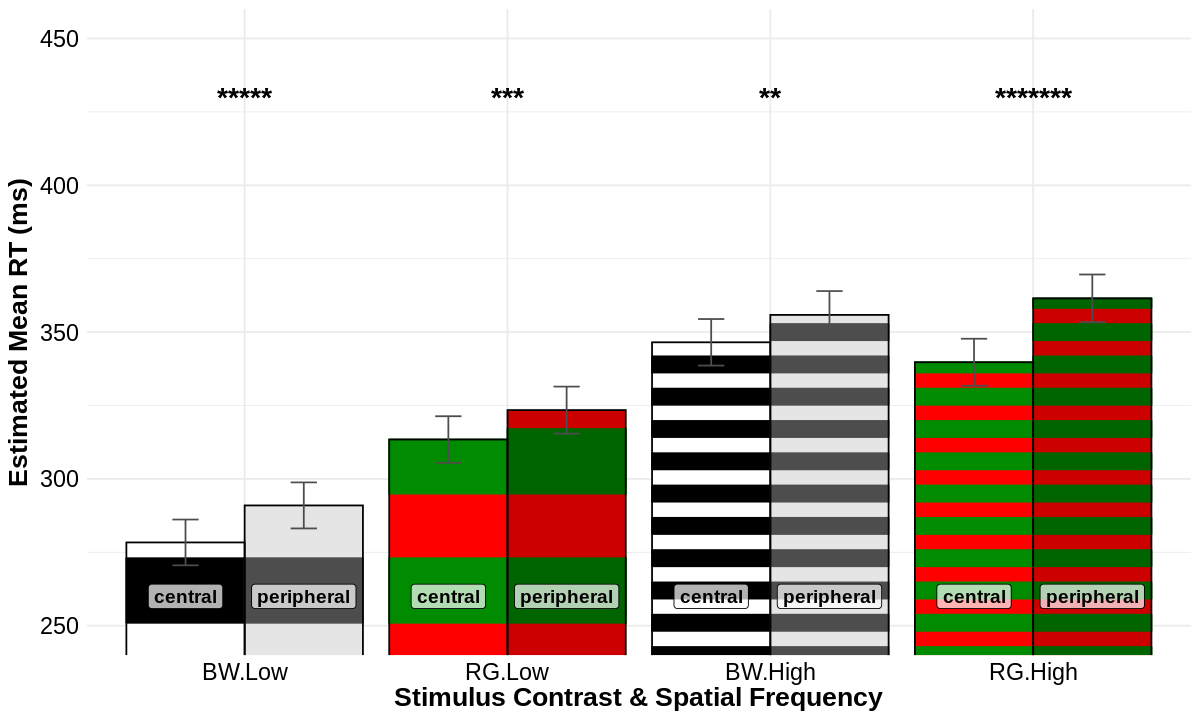

In [72]:
emm_data <- emm_data %>%
  mutate(combo = paste(ruler, frequency, sep = "."),
         combo = factor(combo, levels = c("BW.Low", "RG.Low", "BW.High", "RG.High")))

plot_labels <- data.frame(
  combo = factor(c("BW.Low", "RG.Low", "BW.High", "RG.High"),
                 levels = c("BW.Low", "RG.Low", "BW.High", "RG.High")),
  y_pos = 430,

  sig_stars = c("*****", "***", "**", "*******")
)

alt_g2 <- ggplot(data = emm_data, aes(x = combo, y = emmean, fill = interaction(fixation_cond, combo))) +

  geom_col_pattern(
    aes(pattern = frequency,
        pattern_spacing = frequency,
        pattern_colour = interaction(fixation_cond, combo),
        pattern_fill = interaction(fixation_cond, combo)),
    pattern = "stripe",
    position = position_dodge(0.9),
    pattern_angle = 0,
    pattern_density = .5,
    color = "black"
  ) +
  geom_errorbar(
    aes(ymin = emmean - SE, ymax = emmean + SE, group = interaction(combo, fixation_cond)),
    position = position_dodge(width = 0.9),
    width = 0.2,
    color = "gray30"
  ) +
  coord_cartesian(ylim = c(250, 450)) +
  labs(x = "Stimulus Contrast & Spatial Frequency", y = "Estimated Mean RT (ms)") +

  scale_fill_manual(values = c("white", "gray90", "red", "red3", "white", "gray90", "red", "red3")) +
  scale_pattern_spacing_manual(values = c(0.2, 0.05)) +
  scale_pattern_color_manual(values = c("black","grey30", "green4", "darkgreen", "black","grey30", "green4", "darkgreen")) +
  scale_pattern_fill_manual(values = c("black","grey30", "green4", "darkgreen", "black","grey30", "green4", "darkgreen")) +


  geom_text(data = plot_labels, aes(x = combo, y = y_pos, label = sig_stars),
            size = 6, fontface = "bold", inherit.aes = FALSE) +


  geom_label(aes(y = 260, label = fixation_cond, group = interaction(combo, fixation_cond)),
             fill = "white", alpha = 0.7, fontface = "bold",
             position = position_dodge(0.9), size = 4) +

  theme_minimal() +
  guides(pattern_color = "none", pattern_fill = "none", fill = "none", pattern_spacing = "none") +
  theme(
    axis.text.y = element_text(color = "black", size = 14),
    axis.title.y = element_text(size = 16, face = "bold"),
    axis.text.x = element_text(color = "black", size = 14),
    axis.title.x = element_text(size = 16, face = "bold")
  )
alt_g2

(More than four stars for significance values not standard but visually interesting to see how significant specifically RG High is)

###6.3 Full-Subset Selection for (Linear) Model Comparison

The model selection techniques we learned in class are for linear models which follow normal distributions, so it will be interesting to investigate if the effects hold up for techniques not necessarily suited for RT data. (In this case it may have been better to log transform and run analyses on that data, but then we'd have to appropriately correct estimations to match the units we measured originally to be more grounded). We chose Mallow's CP to prioritize predictive power as the criterion for best model.

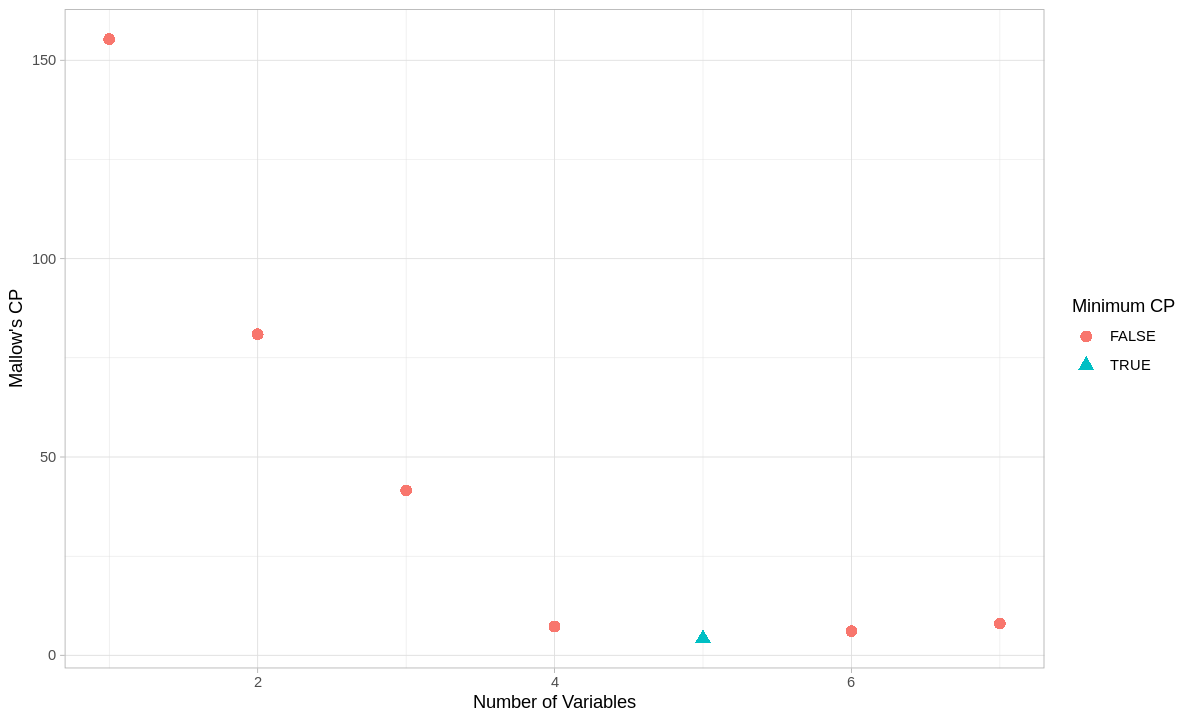

In [73]:
library(leaps)

regfit.full <- regsubsets(rt ~ ruler * frequency * fixation_cond,
                         data = full_C,
                         nvmax = 8)
reg.summary <- summary(regfit.full)

best_cp_model <- which.min(reg.summary$cp)

numvar = 1:length(reg.summary$cp)
allfalse = rep(FALSE,length(reg.summary$cp))

cp.df <- data.frame(numvar = numvar, cp = reg.summary$cp, mincp = allfalse)
cp.df$mincp[which.min(reg.summary$cp)] <- TRUE
ggplot(cp.df,aes(x=numvar,y=cp,shape=mincp,col=mincp)) +
    geom_point(size=3) + theme_light() +
    labs(x = "Number of Variables", y = "Mallow's CP", color="Minimum CP", shape="Minimum CP")

Here we see a steep dropoff in error up to 4 variabes where there's a plateau. Five variables has the best fit according to the plot, so it might be the case that the three-way interaction or potentially (but unlikely) the main effects don't actually add much to our full model.

In [36]:
best_coefs <- coef(regfit.full, 5)

coef_df <- data.frame(
  Model_Term = names(best_coefs),
  Estimate = round(best_coefs, 2))
  rownames(coef_df) <- NULL

  coef_html <- coef_df %>%
  kable(col.names = c("Model Term", "Coefficient Estimate"),
        caption = "Coefficients for the Optimal 5-Variable Model (Mallow's Cp)") %>%
  kable_styling(bootstrap_options = c("striped", "hover", "condensed"),
                full_width = FALSE,
                position = "left")
IRdisplay::display_markdown(paste(coef_html, collapse = "\n"))

<table class="table table-striped table-hover table-condensed" style="width: auto !important; ">
<caption>Coefficients for the Optimal 5-Variable Model (Mallow's Cp)</caption>
 <thead>
  <tr>
   <th style="text-align:left;"> Model Term </th>
   <th style="text-align:right;"> Coefficient Estimate </th>
  </tr>
 </thead>
<tbody>
  <tr>
   <td style="text-align:left;"> (Intercept) </td>
   <td style="text-align:right;"> 275.25 </td>
  </tr>
  <tr>
   <td style="text-align:left;"> rulerRG </td>
   <td style="text-align:right;"> 33.87 </td>
  </tr>
  <tr>
   <td style="text-align:left;"> frequencyHigh </td>
   <td style="text-align:right;"> 66.91 </td>
  </tr>
  <tr>
   <td style="text-align:left;"> fixation_condperipheral </td>
   <td style="text-align:right;"> 10.67 </td>
  </tr>
  <tr>
   <td style="text-align:left;"> rulerRG:frequencyHigh </td>
   <td style="text-align:right;"> -39.03 </td>
  </tr>
  <tr>
   <td style="text-align:left;"> rulerRG:frequencyHigh:fixation_condperipheral </td>
   <td style="text-align:right;"> 11.69 </td>
  </tr>
</tbody>
</table>

The selection dropped two of the two-way interactions to penalize complexity, but strictly retained the 3-way interaction (as well as every main effect). This mathematically demonstrates that the combined effect of Ruler, Frequency, and Fixation is a fundamental predictor of reaction times rather than an additive effect, validating the findings of the Gamma Mixed-Effects model.

###6.4 Permutation Testing on the Three-Way Interaction

To test this three-way interaction once more, a permutation test on the interaction was utilized to compare to a null distribution of interaction effects.

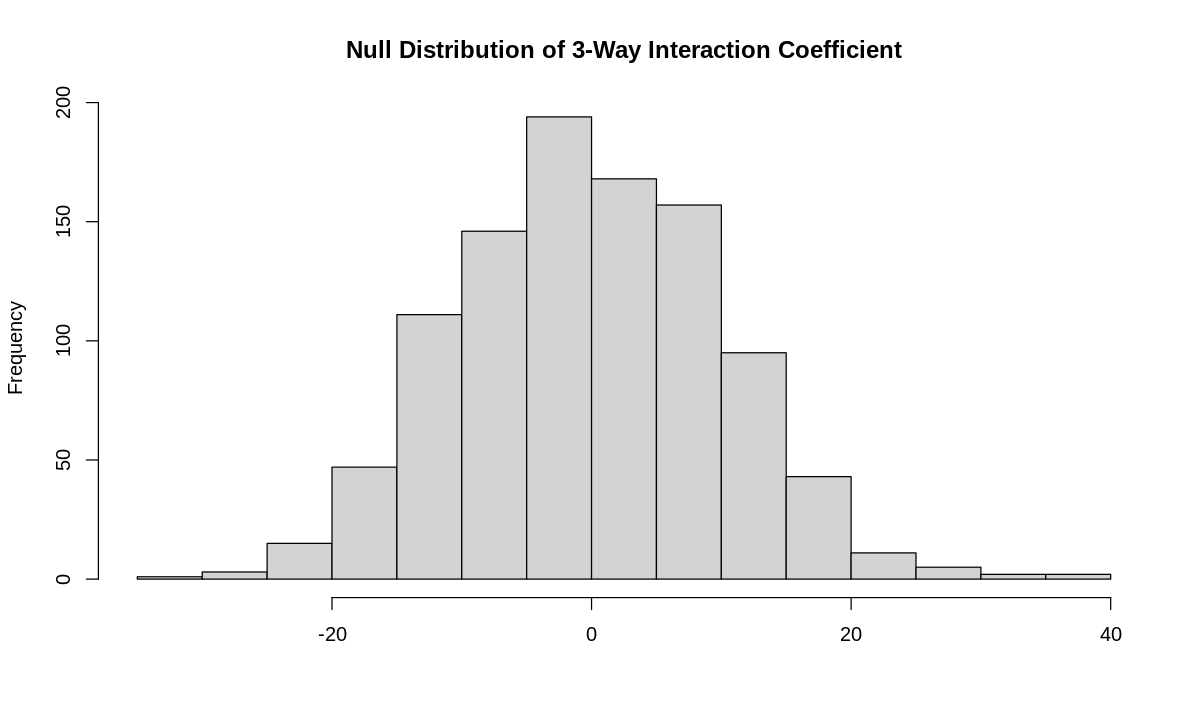

In [52]:
perm_data <- full_C
iterations <- 1000
perm.coefs <- matrix(NA, nrow=iterations, ncol=8)
n_obs = nrow(full_C)

for (i in 1:iterations){
  perm_data$rt = full_C$rt[sample(n_obs)]
  perm.coefs[i,] = coef(lm(rt ~ ruler * frequency * fixation_cond, data = perm_data))
}

hist(perm.coefs[,8],
     main = "Null Distribution of 3-Way Interaction Coefficient",
     xlab = "")

In [43]:
perm.real <- coef(lm(rt ~ ruler * frequency * fixation_cond, data = full_C))
real_df <- data.frame(
  Model_Term = names(perm.real),
  Estimate = round(perm.real, 2))
rownames(real_df) <- NULL

real_html <- real_df %>%
  kable(col.names = c("Model Term", "Actual Coefficient Estimate"),
        caption = "Unpermuted Coefficients (Full 3-Way Model)") %>%
  kable_styling(bootstrap_options = c("striped", "hover", "condensed"),
                full_width = FALSE,
                position = "left")
IRdisplay::display_markdown(paste(real_html, collapse = "\n"))

<table class="table table-striped table-hover table-condensed" style="width: auto !important; ">
<caption>Unpermuted Coefficients (Full 3-Way Model)</caption>
 <thead>
  <tr>
   <th style="text-align:left;"> Model Term </th>
   <th style="text-align:right;"> Actual Coefficient Estimate </th>
  </tr>
 </thead>
<tbody>
  <tr>
   <td style="text-align:left;"> (Intercept) </td>
   <td style="text-align:right;"> 274.41 </td>
  </tr>
  <tr>
   <td style="text-align:left;"> rulerRG </td>
   <td style="text-align:right;"> 34.85 </td>
  </tr>
  <tr>
   <td style="text-align:left;"> frequencyHigh </td>
   <td style="text-align:right;"> 68.49 </td>
  </tr>
  <tr>
   <td style="text-align:left;"> fixation_condperipheral </td>
   <td style="text-align:right;"> 12.35 </td>
  </tr>
  <tr>
   <td style="text-align:left;"> rulerRG:frequencyHigh </td>
   <td style="text-align:right;"> -40.76 </td>
  </tr>
  <tr>
   <td style="text-align:left;"> rulerRG:fixation_condperipheral </td>
   <td style="text-align:right;"> -1.97 </td>
  </tr>
  <tr>
   <td style="text-align:left;"> frequencyHigh:fixation_condperipheral </td>
   <td style="text-align:right;"> -3.17 </td>
  </tr>
  <tr>
   <td style="text-align:left;"> rulerRG:frequencyHigh:fixation_condperipheral </td>
   <td style="text-align:right;"> 15.15 </td>
  </tr>
</tbody>
</table>

In [46]:
perm.p = sum(abs(perm.coefs[, 8]) >= abs(perm.real[8]))/iterations
perm.p

[1] 0.114

As 11.4% of my randomly shuffled three-way interaction coefficients were equal to or greater than the actual coefficient, this test reveals that the interaction we found may not be as stable or valid as initially believed. It is worth noting that, again, this analysis was performed on a linear model of the data, and thus is likely noisier than the generalized mixed model that used a better-fitting gamma distribution.

#**7. CONCLUSIONS**

The present study investigated the functional boundaries of the parvocellular and magnocellular visual pathways using a novel, ecologically valid motion detection task. We found that high spatial frequency patterns elicited slower responses than their low spatial frequency counterparts and that participants were overall slower in their periphery relative to central vision. Most importantly, we found that when comparing central and peripheral RTs for each stimulus, the high spatial frequency, isoluminant red and green meter stick produced the largest performance drop, nearly doubling that of any other stimulus. This effect was non-additive, instead showing an interaction among the factors spatial frequency, luminance contrast, and eccentricity, on visual processing capacities.
It is worth noting that competing evidence from permutation tests on the three-way interaction showed that this non-additive effect may not be stable, but these tests used in class notably expected normal distributions rather than the positively skewed distribution our generalized mixed model fit more accurately.
